In [1]:
import joblib
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

from ml_baselines.modelling.train import train_mlp, train_mlp_grid_search
from ml_baselines.config import Config

In [2]:
cfg = Config()
site = "MHD"

Manually train an MLP model

In [6]:
params_dict = {'activation': 'relu', 'alpha': 0.0001, 'batch_size': 512, 'early_stopping': True, 'hidden_layer_sizes': (100,), 'learning_rate': "constant", 'max_iter': 1000, 'solver': 'adam'}
model, x, y = train_mlp("MHD",
                        balance=0.6,
                        time_shift_hours=[24],
                        mlp_params=params_dict)

Training MLP model for site: MHD
... balancing dataset to target baseline ratio of 0.6
Number of training points: 5290
... number of baseline points: 3174 (60.0%)
... fitting
... predicting
Precision on Training Set = 0.671
Precision on Validation Set = 0.217
Precision on Test Set = 0.294
Recall on Training Set = 0.905
Recall on Validation Set = 0.929
Recall on Test Set = 0.920
F1 Score on Training Set = 0.771
F1 Score on Validation Set = 0.351
F1 Score on Test Set = 0.446


In [55]:
# Save model
met_str = f"-{cfg.met_type}" if cfg.met_type else ""
joblib.dump(model, Path(cfg.models_path) / f"mlp{met_str}_{site}.joblib")

['/Users/chxmr/code/ml-baselines/models/mlp-arco-era5_MHD.joblib']

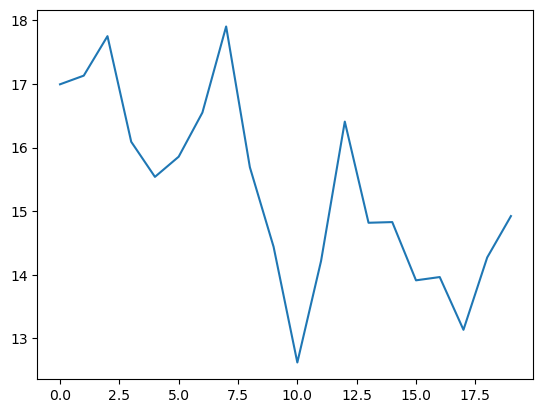

In [7]:
plt.plot(model.loss_curve_)

Run a grid search, including balancing

In [3]:
grid_search = train_mlp_grid_search("MHD", param_grid=None)

... balancing dataset to target baseline ratio of 0.2
Training MLP model for site: MHD with grid search...
Fitting 1 folds for each of 2 candidates, totalling 2 fits
[CV] END activation=relu, alpha=0.0001, batch_size=50, early_stopping=False, hidden_layer_sizes=50, learning_rate=constant, max_iter=1000, shuffle=False, solver=adam; total time=   0.8s
[CV] END activation=relu, alpha=0.0001, batch_size=50, early_stopping=False, hidden_layer_sizes=(100,), learning_rate=constant, max_iter=1000, shuffle=False, solver=adam; total time=   1.3s
Best parameters found:  {'activation': 'relu', 'alpha': 0.0001, 'batch_size': 50, 'early_stopping': False, 'hidden_layer_sizes': (100,), 'learning_rate': 'constant', 'max_iter': 1000, 'shuffle': False, 'solver': 'adam'}
Best score:  0.07970112079701121
... balancing dataset to target baseline ratio of 0.30000000000000004
Training MLP model for site: MHD with grid search...
Fitting 1 folds for each of 2 candidates, totalling 2 fits
[CV] END activation=rel

/Users/chxmr/opt/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
